# 🏦 Análise do Mercado de Crédito Brasileiro — API Banco Central

**Objetivo:** Identificar oportunidades de crédito por estado e região, apoiando decisões estratégicas de expansão para empresas do setor financeiro.

**Fonte de dados:** API pública do Banco Central do Brasil (BCB / BACEN)  
**Biblioteca principal:** `python-bcb` + `requests` direto na API SGS  

---
### 📋 Estrutura do Notebook

| # | Seção | Descrição |
|---|-------|-----------|
| 0 | Setup | Instalação e imports |
| 1 | ETL 1 | Inadimplência por Estado (PF / PJ / Total) |
| 2 | ETL 2 | Saldo de Crédito Nacional e Indicadores Macro |
| 3 | ETL 3 | Taxas de Juros por Modalidade |
| 4 | ETL 4 | Séries Regionais Complementares |
| 5 | Análise | Exploração — Brasil Geral |
| 6 | Análise | Por Macrorregião |
| 7 | Análise | Por Estado (UF) |
| 8 | Score | Mapa de Oportunidades de Crédito |
| 9 | Export | Exportar resultados |

---
> ⚡ **Executar no Google Colab:** Runtime → Run all  
> 📅 Dados atualizados automaticamente via API — sem arquivos locais necessários

---
## 0️⃣ Setup — Instalação e Configurações

In [1]:
# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
!pip install python-bcb pandas numpy matplotlib seaborn plotly requests --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import requests
import warnings
from datetime import datetime, date

# python-bcb
from bcb import sgs
from bcb.sgs.regional_economy import get_non_performing_loans
from bcb.utils import BRAZILIAN_REGIONS, BRAZILIAN_STATES
from bcb import TaxaJuros

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

print("✅ Imports concluídos com sucesso!")
print(f"📅 Data de execução: {datetime.now().strftime('%d/%m/%Y %H:%M')}")

✅ Imports concluídos com sucesso!
📅 Data de execução: 16/03/2026 20:44


In [3]:
# ============================================================
# PARÂMETROS GLOBAIS
# ============================================================

# Período de análise
START_DATE = '2019-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

# Mapeamento de estados por macrorregião
REGIOES = {
    'Norte':       ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO'],
    'Nordeste':    ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'],
    'Centro-Oeste':['DF', 'GO', 'MS', 'MT'],
    'Sudeste':     ['ES', 'MG', 'RJ', 'SP'],
    'Sul':         ['PR', 'RS', 'SC'],
}

# Cores por região
CORES_REGIAO = {
    'Norte':        '#1a1a6e',   # azul escuro
    'Nordeste':     '#7b2d8b',   # roxo
    'Centro-Oeste': '#e05c5c',   # vermelho-rosa
    'Sudeste':      '#e8a87c',   # laranja claro
    'Sul':          '#4b0082',   # índigo
}

# Dicionário inverso: UF -> Região
UF_PARA_REGIAO = {
    uf: regiao
    for regiao, estados in REGIOES.items()
    for uf in estados
}

print("✅ Parâmetros configurados")
print(f"   Período: {START_DATE} → {END_DATE}")
print(f"   Total de estados: {sum(len(v) for v in REGIOES.values())}")

✅ Parâmetros configurados
   Período: 2019-01-01 → 2026-03-16
   Total de estados: 27


In [4]:
# ============================================================
# FUNÇÕES UTILITÁRIAS
# ============================================================

def fetch_sgs_series(codigo, nome, start=START_DATE):
    """Busca uma série temporal do SGS/BCB pela API REST."""
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
        f"?formato=json&dataInicial={pd.Timestamp(start).strftime('%d/%m/%Y')}"
    )
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        df = pd.DataFrame(resp.json())
        df['data'] = pd.to_datetime(df['data'], dayfirst=True)
        df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
        df = df.rename(columns={'data': 'Data', 'valor': nome}).set_index('Data')
        return df
    except Exception as e:
        print(f"  ⚠️  Série {codigo} ({nome}) não disponível: {e}")
        return pd.DataFrame()


def fetch_multiplas_series(series_dict, start=START_DATE):
    """
    Busca e concatena múltiplas séries SGS.
    series_dict = {'nome_coluna': codigo_sgs}
    """
    frames = []
    for nome, cod in series_dict.items():
        df = fetch_sgs_series(cod, nome, start=start)
        if not df.empty:
            frames.append(df)
            print(f"  ✅ {nome} (SGS {cod}): {len(df)} observações")
    if frames:
        return pd.concat(frames, axis=1)
    return pd.DataFrame()


def adicionar_regiao(df_uf):
    """Adiciona coluna de macrorregião a um DataFrame com coluna 'UF'."""
    df_uf = df_uf.copy()
    df_uf['Regiao'] = df_uf['UF'].map(UF_PARA_REGIAO)
    return df_uf


def minmax_normalizar(serie):
    """Normaliza uma série para o intervalo [0, 1]."""
    return (serie - serie.min()) / (serie.max() - serie.min())


print("✅ Funções utilitárias definidas")

✅ Funções utilitárias definidas


---
## 1️⃣ ETL 1 — Inadimplência por Estado (PF / PJ / Total)

**Fonte:** BCB / SGS — Dados de Inadimplência das Operações de Crédito  
**Cobertura:** Todos os 27 estados + DF  
**Granularidade:** Mensal por UF  

> Inadimplência = % das operações de crédito com atraso acima de 90 dias

In [5]:
# ============================================================
# ETL 1 — INADIMPLÊNCIA POR ESTADO
# ============================================================
print("🔄 Buscando dados de inadimplência por estado...\n")

TODOS_OS_ESTADOS = [uf for estados in REGIOES.values() for uf in estados]

# --- 1.1 Inadimplência Total (PF + PJ)
print("📥 Inadimplência Total...")
inadimplencia_total = get_non_performing_loans(
    TODOS_OS_ESTADOS, mode='all', start=START_DATE
)

# --- 1.2 Inadimplência Pessoa Física
print("📥 Inadimplência Pessoa Física...")
inadimplencia_pf = get_non_performing_loans(
    TODOS_OS_ESTADOS, mode='pf', start=START_DATE
)

# --- 1.3 Inadimplência Pessoa Jurídica
print("📥 Inadimplência Pessoa Jurídica...")
inadimplencia_pj = get_non_performing_loans(
    TODOS_OS_ESTADOS, mode='pj', start=START_DATE
)

print(f"\n✅ Dados de inadimplência carregados")
print(f"   Período: {inadimplencia_total.index.min().date()} → {inadimplencia_total.index.max().date()}")
print(f"   Estados: {inadimplencia_total.shape[1]}")
print(f"   Observações: {inadimplencia_total.shape[0]} meses x {inadimplencia_total.shape[1]} UFs")

🔄 Buscando dados de inadimplência por estado...

📥 Inadimplência Total...
📥 Inadimplência Pessoa Física...
📥 Inadimplência Pessoa Jurídica...

✅ Dados de inadimplência carregados
   Período: 2019-01-01 → 2026-01-01
   Estados: 27
   Observações: 85 meses x 27 UFs


In [6]:
# --- Transformação: pivot para formato long (tidy data)
def wide_to_long(df, nome_variavel):
    """Converte DataFrame wide (UFs como colunas) para formato long."""
    return (
        df.reset_index()
          .melt(id_vars='Date', var_name='UF', value_name=nome_variavel)
          .assign(Regiao=lambda d: d['UF'].map(UF_PARA_REGIAO))
          .rename(columns={'Date': 'Data'})
    )

inadimplencia_long = (
    wide_to_long(inadimplencia_total, 'Inadimplencia_Total')
    .merge(
        wide_to_long(inadimplencia_pf,    'Inadimplencia_PF')[['Data','UF','Inadimplencia_PF']],
        on=['Data','UF'], how='left'
    )
    .merge(
        wide_to_long(inadimplencia_pj,    'Inadimplencia_PJ')[['Data','UF','Inadimplencia_PJ']],
        on=['Data','UF'], how='left'
    )
)

print("📊 Preview — Inadimplência (formato long):")
inadimplencia_long.tail(10)

📊 Preview — Inadimplência (formato long):


,Data,UF,Inadimplencia_Total,Regiao,Inadimplencia_PF,Inadimplencia_PJ
2285,2025-04-01,SC,2.85,Sul,3.26,2.35
2286,2025-05-01,SC,2.98,Sul,3.39,2.47
2287,2025-06-01,SC,3.02,Sul,3.43,2.52
2288,2025-07-01,SC,3.16,Sul,3.59,2.63
2289,2025-08-01,SC,3.27,Sul,3.72,2.72
2290,2025-09-01,SC,3.16,Sul,3.61,2.60
2291,2025-10-01,SC,3.22,Sul,3.74,2.56
2292,2025-11-01,SC,3.28,Sul,3.78,2.63
2293,2025-12-01,SC,3.22,Sul,3.77,2.52
2294,2026-01-01,SC,3.43,Sul,3.99,2.72


In [7]:
# --- Resumo estatístico da inadimplência mais recente por UF
inadimplencia_recente = (
    inadimplencia_long
    .dropna(subset=['Inadimplencia_Total'])
    .sort_values('Data')
    .groupby('UF')
    .last()
    .reset_index()[['UF', 'Regiao', 'Inadimplencia_Total', 'Inadimplencia_PF', 'Inadimplencia_PJ']]
    .sort_values('Inadimplencia_Total', ascending=False)
)

print("📊 Inadimplência mais recente por UF (ordenada):")
inadimplencia_recente.style.background_gradient(
    subset=['Inadimplencia_Total','Inadimplencia_PF','Inadimplencia_PJ'],
    cmap='RdYlGn_r'
).format({'Inadimplencia_Total': '{:.2f}%', 'Inadimplencia_PF': '{:.2f}%', 'Inadimplencia_PJ': '{:.2f}%'})

📊 Inadimplência mais recente por UF (ordenada):


,UF,Regiao,Inadimplencia_Total,Inadimplencia_PF,Inadimplencia_PJ
9,MA,Nordeste,7.89%,8.39%,6.11%
26,TO,Norte,7.84%,9.03%,4.56%
11,MS,Centro-Oeste,6.44%,7.17%,4.56%
8,GO,Centro-Oeste,6.37%,7.08%,4.24%
20,RO,Norte,6.06%,6.05%,6.13%
12,MT,Centro-Oeste,5.89%,6.58%,4.26%
13,PA,Norte,5.66%,6.22%,4.34%
14,PB,Nordeste,5.48%,4.72%,8.58%
21,RR,Norte,5.43%,5.81%,4.19%
2,AM,Norte,5.26%,6.29%,3.76%


---
## 2️⃣ ETL 2 — Saldo de Crédito e Indicadores Macroeconômicos

**Fonte:** BCB SGS — API REST direta  
**Séries:** Crédito total, PF, PJ, IPCA, Selic, PIB  
**Granularidade:** Nacional (mensal/trimestral)

In [8]:
# ============================================================
# ETL 2 — SALDO DE CRÉDITO NACIONAL + MACRO
# ============================================================
print("🔄 Buscando indicadores macroeconômicos e saldo de crédito nacional...\n")

SERIES_MACRO = {
    # Crédito — Saldo Total (R$ bilhões)
    'Credito_Total_SFN':        20539,   # Saldo total crédito SFN
    'Credito_PF':               20540,   # Saldo crédito Pessoa Física
    'Credito_PJ':               20541,   # Saldo crédito Pessoa Jurídica
    'Credito_Livre_Total':      20542,   # Crédito livre total
    'Credito_Direcionado_Total': 20543,  # Crédito direcionado total

    # Inadimplência Nacional
    'Inadimplencia_Nacional_Total': 21082, # Inadimplência total SFN
    'Inadimplencia_Nacional_PF':    21083, # Inadimplência PF
    'Inadimplencia_Nacional_PJ':    21084, # Inadimplência PJ

    # Macro
    'IPCA_Mensal':        433,   # Inflação IPCA (%)
    'Selic_Meta':           432,  # Meta taxa Selic (%)
    'Selic_Efetiva':      4189,   # Taxa Selic efetiva
}

df_macro = fetch_multiplas_series(SERIES_MACRO, start=START_DATE)

print(f"\n✅ Indicadores nacionais carregados: {df_macro.shape[1]} séries, {df_macro.shape[0]} observações")
df_macro.tail()

🔄 Buscando indicadores macroeconômicos e saldo de crédito nacional...

  ✅ Credito_Total_SFN (SGS 20539): 85 observações
  ✅ Credito_PF (SGS 20540): 85 observações
  ✅ Credito_PJ (SGS 20541): 85 observações
  ✅ Credito_Livre_Total (SGS 20542): 85 observações
  ✅ Credito_Direcionado_Total (SGS 20543): 85 observações
  ✅ Inadimplencia_Nacional_Total (SGS 21082): 85 observações
  ✅ Inadimplencia_Nacional_PF (SGS 21083): 85 observações
  ✅ Inadimplencia_Nacional_PJ (SGS 21084): 85 observações
  ✅ IPCA_Mensal (SGS 433): 86 observações
  ✅ Selic_Meta (SGS 432): 2634 observações
  ✅ Selic_Efetiva (SGS 4189): 87 observações

✅ Indicadores nacionais carregados: 11 séries, 2634 observações


,Credito_Total_SFN,Credito_PF,Credito_PJ,Credito_Livre_Total,Credito_Direcionado_Total,Inadimplencia_Nacional_Total,Inadimplencia_Nacional_PF,Inadimplencia_Nacional_PJ,IPCA_Mensal,Selic_Meta,Selic_Efetiva
Data,,,,,,,,,,,
2026-03-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN
2026-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN
2026-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN
2026-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN
2026-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.00,NaN


In [9]:
# --- Séries de Crédito por Macrorregião (SGS) ---
# O BCB publica saldos de crédito por macrorregião (códigos 20544-20548)
print("🔄 Buscando saldo de crédito por macrorregião...\n")

SERIES_REGIOES_CREDITO = {
    'Credito_Norte':         20544,
    'Credito_Nordeste':      20545,
    'Credito_Sudeste':       20546,
    'Credito_Sul':           20547,
    'Credito_Centro_Oeste':  20548,
}

df_credito_regiao = fetch_multiplas_series(SERIES_REGIOES_CREDITO, start=START_DATE)

# Inadimplência por macrorregião
print("\n🔄 Buscando inadimplência por macrorregião...\n")
SERIES_INADIM_REGIAO = {
    'Inadim_Norte':         20549,
    'Inadim_Nordeste':      20550,
    'Inadim_Sudeste':       20551,
    'Inadim_Sul':           20552,
    'Inadim_Centro_Oeste':  20553,
}

df_inadim_regiao = fetch_multiplas_series(SERIES_INADIM_REGIAO, start=START_DATE)

print("\n✅ Dados regionais carregados")

🔄 Buscando saldo de crédito por macrorregião...

  ✅ Credito_Norte (SGS 20544): 85 observações
  ✅ Credito_Nordeste (SGS 20545): 85 observações
  ✅ Credito_Sudeste (SGS 20546): 85 observações
  ✅ Credito_Sul (SGS 20547): 85 observações
  ✅ Credito_Centro_Oeste (SGS 20548): 85 observações

🔄 Buscando inadimplência por macrorregião...

  ✅ Inadim_Norte (SGS 20549): 85 observações
  ✅ Inadim_Nordeste (SGS 20550): 85 observações
  ✅ Inadim_Sudeste (SGS 20551): 85 observações
  ✅ Inadim_Sul (SGS 20552): 85 observações
  ✅ Inadim_Centro_Oeste (SGS 20553): 85 observações

✅ Dados regionais carregados


In [10]:
# --- Transformação: calcular participação percentual de cada região no crédito total ---
if not df_credito_regiao.empty and 'Credito_Total_SFN' in df_macro.columns:
    regioes_cols = list(SERIES_REGIOES_CREDITO.keys())
    df_credito_regiao_pct = df_credito_regiao.copy()

    total_aligned = df_macro['Credito_Total_SFN'].reindex(df_credito_regiao.index)
    for col in regioes_cols:
        if col in df_credito_regiao_pct.columns:
            nome_pct = col.replace('Credito_', 'Pct_')
            df_credito_regiao_pct[nome_pct] = (
                df_credito_regiao_pct[col] / total_aligned * 100
            )

    print("📊 Participação das regiões no crédito total (últimas 6 obs.):")
    pct_cols = [c for c in df_credito_regiao_pct.columns if c.startswith('Pct_')]
    df_credito_regiao_pct[pct_cols].dropna().tail(6)

📊 Participação das regiões no crédito total (últimas 6 obs.):


---
## 3️⃣ ETL 3 — Taxas de Juros por Modalidade

**Fonte:** BCB — API OData `TaxaJuros`  
**Conteúdo:** Taxas médias por modalidade, segmento (PF/PJ), instituição  
**Granularidade:** Semanal / Mensal

In [11]:
# ============================================================
# ETL 3 — TAXAS DE JUROS POR MODALIDADE
# ============================================================
print("🔄 Buscando taxas de juros via OData...")

try:
    tj = TaxaJuros()

    # Explorar endpoints disponíveis
    tj.describe()
except Exception as e:
    print(f"⚠️  Erro ao inicializar TaxaJuros: {e}")

🔄 Buscando taxas de juros via OData...
EntitySets:
  TaxasJurosMensalPorMes
  ParametrosConsulta
  TaxasJurosDiariaPorInicioPeriodo
  ConsultaUnificada
  ConsultaDatas


In [12]:
# --- Taxas de juros médias por modalidade ---
try:
    ep_mensal = tj.get_endpoint('TaxasJurosMercadoCreditoPF')
    df_juros_pf = (
        ep_mensal.query()
        .filter(ep_mensal.Modalidade == 'Total')
        .select('Ano', 'Mes', 'TaxaJurosAoMes', 'TaxaJurosAoAno')
        .collect()
    )
    print("✅ Taxas PF carregadas")
    print(df_juros_pf.tail())
except Exception as e:
    print(f"  ℹ️  Endpoint PF não disponível neste formato: {e}")
    print("     Usando SGS como fallback...")

    # Fallback: taxas por modalidade via SGS direto
    SERIES_JUROS = {
        'Juros_Total_PF_am':       25466,  # Taxa juros PF total ao mês
        'Juros_Total_PJ_am':       25467,  # Taxa juros PJ total ao mês
        'Juros_Pessoal_am':        25401,  # Crédito pessoal ao mês
        'Juros_Consignado_am':     25402,  # Crédito consignado ao mês
        'Juros_Veiculos_am':       25404,  # Veículos ao mês
        'Juros_CartaoCredito_am':  25403,  # Cartão de crédito ao mês
        'Juros_Imobiliario_am':    25406,  # Crédito imobiliário ao mês
    }

    df_juros = fetch_multiplas_series(SERIES_JUROS, start=START_DATE)
    if not df_juros.empty:
        print(f"\n✅ Taxas de juros carregadas via SGS: {df_juros.shape[1]} modalidades")
        print(df_juros.tail())

  ℹ️  Endpoint PF não disponível neste formato: Invalid name: TaxasJurosMercadoCreditoPF
     Usando SGS como fallback...
  ✅ Juros_Total_PF_am (SGS 25466): 85 observações
  ✅ Juros_Total_PJ_am (SGS 25467): 85 observações
  ✅ Juros_Pessoal_am (SGS 25401): 84 observações
  ✅ Juros_Consignado_am (SGS 25402): 84 observações
  ✅ Juros_Veiculos_am (SGS 25404): 84 observações
  ⚠️  Série 25403 (Juros_CartaoCredito_am) não disponível: 502 Server Error: Bad Gateway for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.25403/dados?formato=json&dataInicial=01/01/2019
  ✅ Juros_Imobiliario_am (SGS 25406): 84 observações

✅ Taxas de juros carregadas via SGS: 6 modalidades
            Juros_Total_PF_am  Juros_Total_PJ_am  Juros_Pessoal_am  \
Data                                                                 
2025-09-01               3.91               1.84            103.93   
2025-10-01               3.94               1.85            106.82   
2025-11-01               3.84               1.79  

---
## 4️⃣ ETL 4 — Séries Complementares (Spread, PIX, Bancarização)

Séries adicionais para enriquecer a análise de oportunidade.

In [13]:
# ============================================================
# ETL 4 — SÉRIES COMPLEMENTARES
# ============================================================
print("🔄 Buscando séries complementares...\n")

SERIES_COMPLEMENTARES = {
    # Spread bancário
    'Spread_PF_Total':       25436,  # Spread médio PF
    'Spread_PJ_Total':       25437,  # Spread médio PJ

    # Concessões mensais de crédito (novas operações)
    'Concessoes_Total':      20631,  # Concessões totais
    'Concessoes_PF':         20632,  # Concessões PF
    'Concessoes_PJ':         20633,  # Concessões PJ

    # Comprometimento de renda
    'Comprom_Renda_PF':      19882,  # % renda comprometida com crédito (PF)

    # Endividamento das famílias
    'Endividamento_Familias': 29037, # % endividamento famílias

    # PIX - transações
    'PIX_Transacoes_Qtd':    27825,  # Qtd transações PIX
    'PIX_Transacoes_Valor':  27826,  # Valor transações PIX
}

df_complementar = fetch_multiplas_series(SERIES_COMPLEMENTARES, start=START_DATE)

print(f"\n✅ Séries complementares: {df_complementar.shape[1] if not df_complementar.empty else 0} séries")

🔄 Buscando séries complementares...

  ✅ Spread_PF_Total (SGS 25436): 85 observações
  ✅ Spread_PJ_Total (SGS 25437): 85 observações
  ✅ Concessoes_Total (SGS 20631): 85 observações
  ✅ Concessoes_PF (SGS 20632): 85 observações
  ✅ Concessoes_PJ (SGS 20633): 85 observações
  ✅ Comprom_Renda_PF (SGS 19882): 32 observações
  ✅ Endividamento_Familias (SGS 29037): 84 observações
  ⚠️  Série 27825 (PIX_Transacoes_Qtd) não disponível: HTTPSConnectionPool(host='api.bcb.gov.br', port=443): Read timed out. (read timeout=30)
  ⚠️  Série 27826 (PIX_Transacoes_Valor) não disponível: HTTPSConnectionPool(host='api.bcb.gov.br', port=443): Read timed out. (read timeout=30)

✅ Séries complementares: 7 séries


In [14]:
# --- Consolidação final dos ETLs ---
print("=" * 60)
print("📦 RESUMO DOS ETLs CARREGADOS")
print("=" * 60)

etls = {
    'ETL1 - Inadimplência por Estado (long)': inadimplencia_long,
    'ETL1 - Inadimplência PF (wide)':         inadimplencia_pf,
    'ETL1 - Inadimplência PJ (wide)':         inadimplencia_pj,
    'ETL1 - Inadimplência Total (wide)':      inadimplencia_total,
    'ETL2 - Indicadores Macro':               df_macro,
    'ETL2 - Crédito por Região':              df_credito_regiao,
    'ETL4 - Séries Complementares':           df_complementar,
}

for nome, df in etls.items():
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(f"  ✅ {nome}: {df.shape[0]} obs x {df.shape[1]} cols")
    else:
        print(f"  ⚠️  {nome}: vazio ou não carregado")

📦 RESUMO DOS ETLs CARREGADOS
  ✅ ETL1 - Inadimplência por Estado (long): 2295 obs x 6 cols
  ✅ ETL1 - Inadimplência PF (wide): 85 obs x 27 cols
  ✅ ETL1 - Inadimplência PJ (wide): 85 obs x 27 cols
  ✅ ETL1 - Inadimplência Total (wide): 85 obs x 27 cols
  ✅ ETL2 - Indicadores Macro: 2634 obs x 11 cols
  ✅ ETL2 - Crédito por Região: 85 obs x 5 cols
  ✅ ETL4 - Séries Complementares: 85 obs x 7 cols


---
## 5️⃣ Análise — Brasil Geral 🇧🇷

Evolução temporal dos principais indicadores de crédito a nível nacional.

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig1_brasil_geral.png'

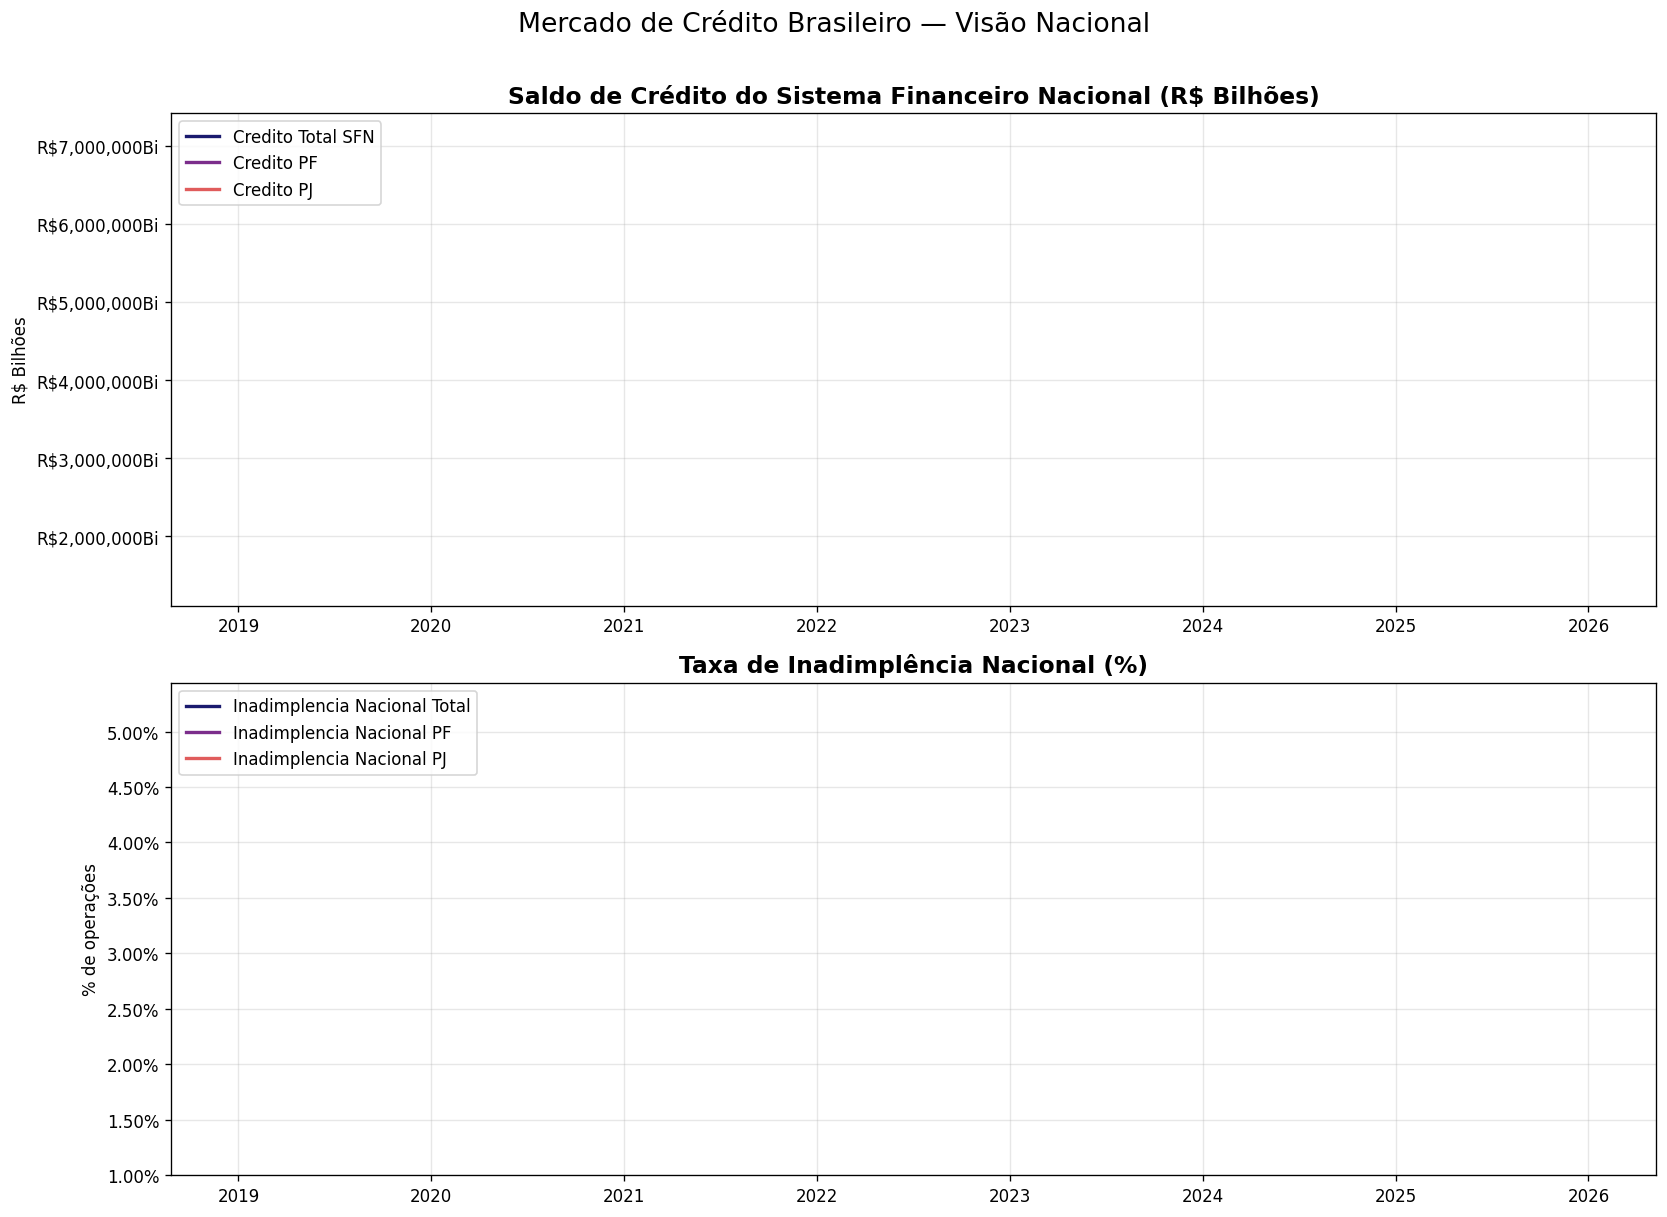

In [15]:
# ============================================================
# ANÁLISE 1 — SALDO DE CRÉDITO NACIONAL (EVOLUÇÃO)
# ============================================================
cols_credito = ['Credito_Total_SFN', 'Credito_PF', 'Credito_PJ']
cols_disponiveis = [c for c in cols_credito if c in df_macro.columns]

if cols_disponiveis:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Gráfico 1: Saldo absoluto
    ax1 = axes[0]
    cores = ['#1a1a6e', '#7b2d8b', '#e05c5c']
    for col, cor in zip(cols_disponiveis, cores):
        ax1.plot(df_macro.index, df_macro[col], label=col.replace('_', ' '), color=cor, lw=2)
    ax1.set_title('Saldo de Crédito do Sistema Financeiro Nacional (R$ Bilhões)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('R$ Bilhões')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f'R${x:,.0f}Bi'))

    # Gráfico 2: Inadimplência Nacional
    ax2 = axes[1]
    inadim_cols = ['Inadimplencia_Nacional_Total', 'Inadimplencia_Nacional_PF', 'Inadimplencia_Nacional_PJ']
    inadim_disp = [c for c in inadim_cols if c in df_macro.columns]
    for col, cor in zip(inadim_disp, cores):
        ax2.plot(df_macro.index, df_macro[col], label=col.replace('_', ' '), color=cor, lw=2)
    ax2.set_title('Taxa de Inadimplência Nacional (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('% de operações')
    ax2.legend()
    ax2.grid(alpha=0.3)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

    plt.suptitle('Mercado de Crédito Brasileiro — Visão Nacional', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig('/content/fig1_brasil_geral.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Figura salva: fig1_brasil_geral.png")

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig2_macro.png'

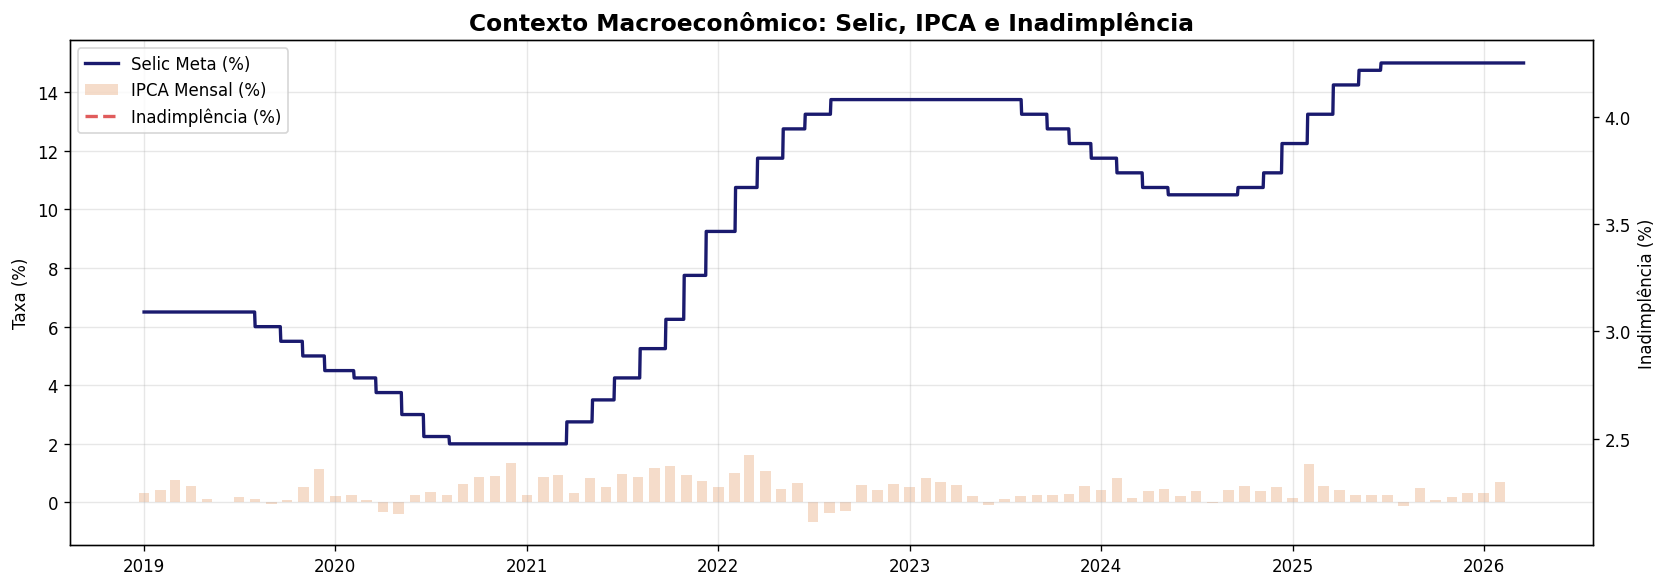

In [16]:
# ============================================================
# ANÁLISE 2 — SELIC x IPCA x INADIMPLÊNCIA
# ============================================================
cols_macro = ['IPCA_Mensal', 'Selic_Meta', 'Inadimplencia_Nacional_Total']
cols_disp = [c for c in cols_macro if c in df_macro.columns]

if len(cols_disp) >= 2:
    fig, ax1 = plt.subplots(figsize=(14, 5))

    ax2 = ax1.twinx()

    if 'IPCA_Mensal' in df_macro.columns:
        ax1.bar(df_macro.index, df_macro['IPCA_Mensal'], alpha=0.4, color='#e8a87c', label='IPCA Mensal (%)', width=20)
    if 'Selic_Meta' in df_macro.columns:
        ax1.plot(df_macro.index, df_macro['Selic_Meta'], color='#1a1a6e', lw=2, label='Selic Meta (%)')
    if 'Inadimplencia_Nacional_Total' in df_macro.columns:
        ax2.plot(df_macro.index, df_macro['Inadimplencia_Nacional_Total'],
                 color='#e05c5c', lw=2, linestyle='--', label='Inadimplência (%)')

    ax1.set_title('Contexto Macroeconômico: Selic, IPCA e Inadimplência', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Taxa (%)')
    ax2.set_ylabel('Inadimplência (%)')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    ax1.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/fig2_macro.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6️⃣ Análise por Macrorregião 🗺️

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig3_inadimplencia_regiao.png'

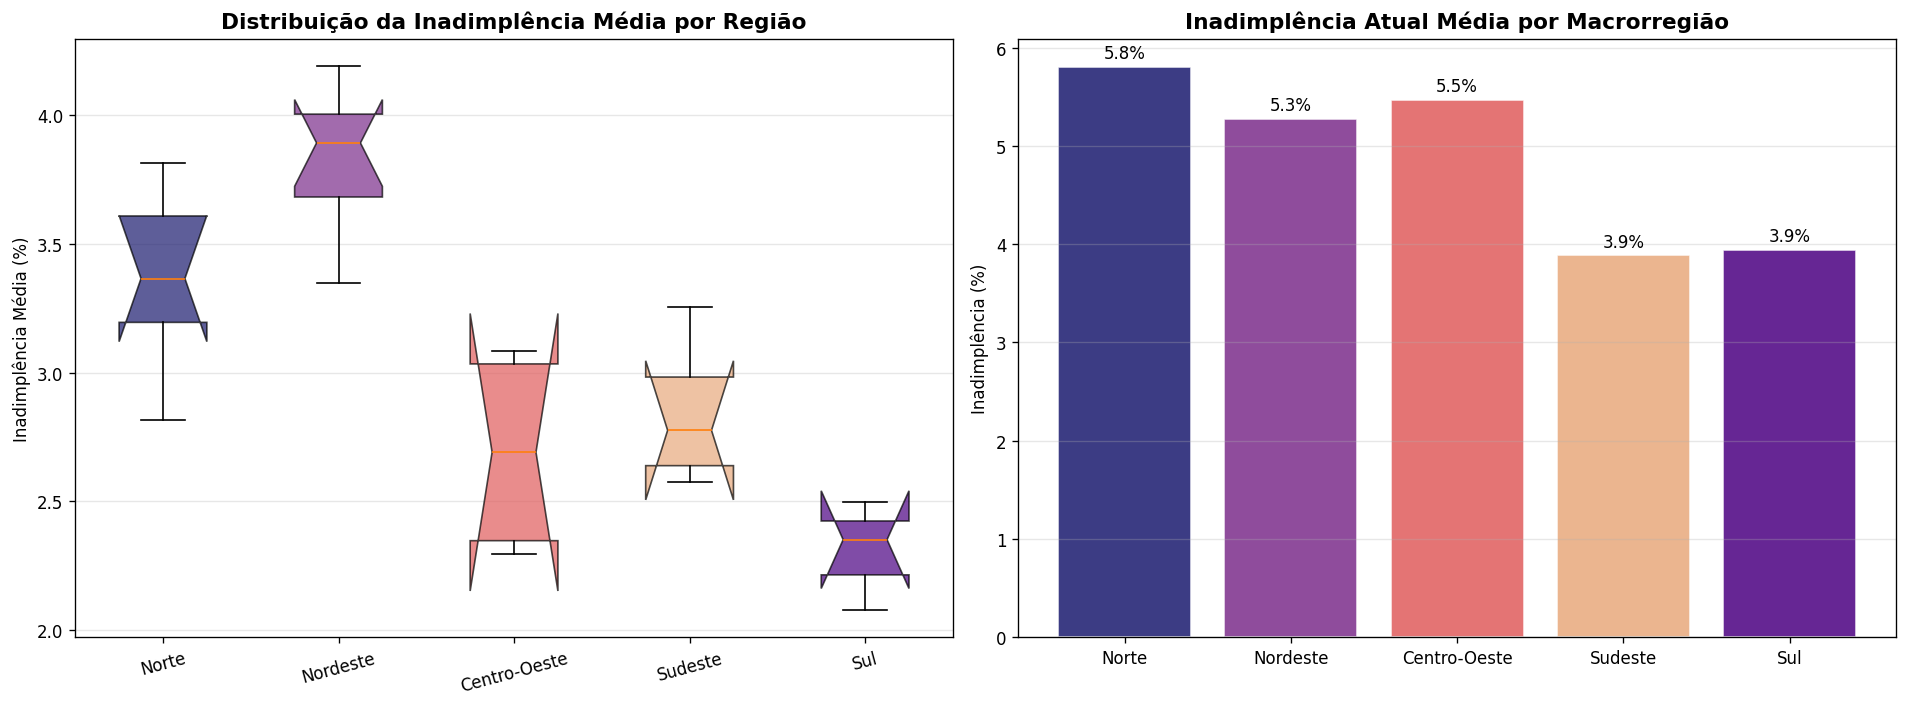

In [17]:
# ============================================================
# ANÁLISE 3 — INADIMPLÊNCIA POR REGIÃO (BOXPLOT)
# ============================================================
# Calcular média de inadimplência recente por UF e Região
inadim_media_uf = (
    inadimplencia_long
    .dropna(subset=['Inadimplencia_Total'])
    .groupby(['UF', 'Regiao'])['Inadimplencia_Total']
    .agg(['mean', 'std', 'last'])
    .reset_index()
    .rename(columns={'mean': 'Media', 'std': 'Desvio', 'last': 'Ultimo'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot por região
ax = axes[0]
ordem_regioes = list(REGIOES.keys())
dados_box = [
    inadim_media_uf[inadim_media_uf['Regiao'] == r]['Media'].values
    for r in ordem_regioes
]
bp = ax.boxplot(dados_box, labels=ordem_regioes, patch_artist=True, notch=True)
for patch, regiao in zip(bp['boxes'], ordem_regioes):
    patch.set_facecolor(CORES_REGIAO[regiao])
    patch.set_alpha(0.7)
ax.set_title('Distribuição da Inadimplência Média por Região', fontsize=13, fontweight='bold')
ax.set_ylabel('Inadimplência Média (%)')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)

# Barras: média por região
ax2 = axes[1]
media_regiao = inadim_media_uf.groupby('Regiao')['Ultimo'].mean().reindex(ordem_regioes)
cores_bar = [CORES_REGIAO[r] for r in ordem_regioes]
bars = ax2.bar(media_regiao.index, media_regiao.values, color=cores_bar, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, media_regiao.values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.05, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax2.set_title('Inadimplência Atual Média por Macrorregião', fontsize=13, fontweight='bold')
ax2.set_ylabel('Inadimplência (%)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig3_inadimplencia_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig4_evolucao_regiao.png'

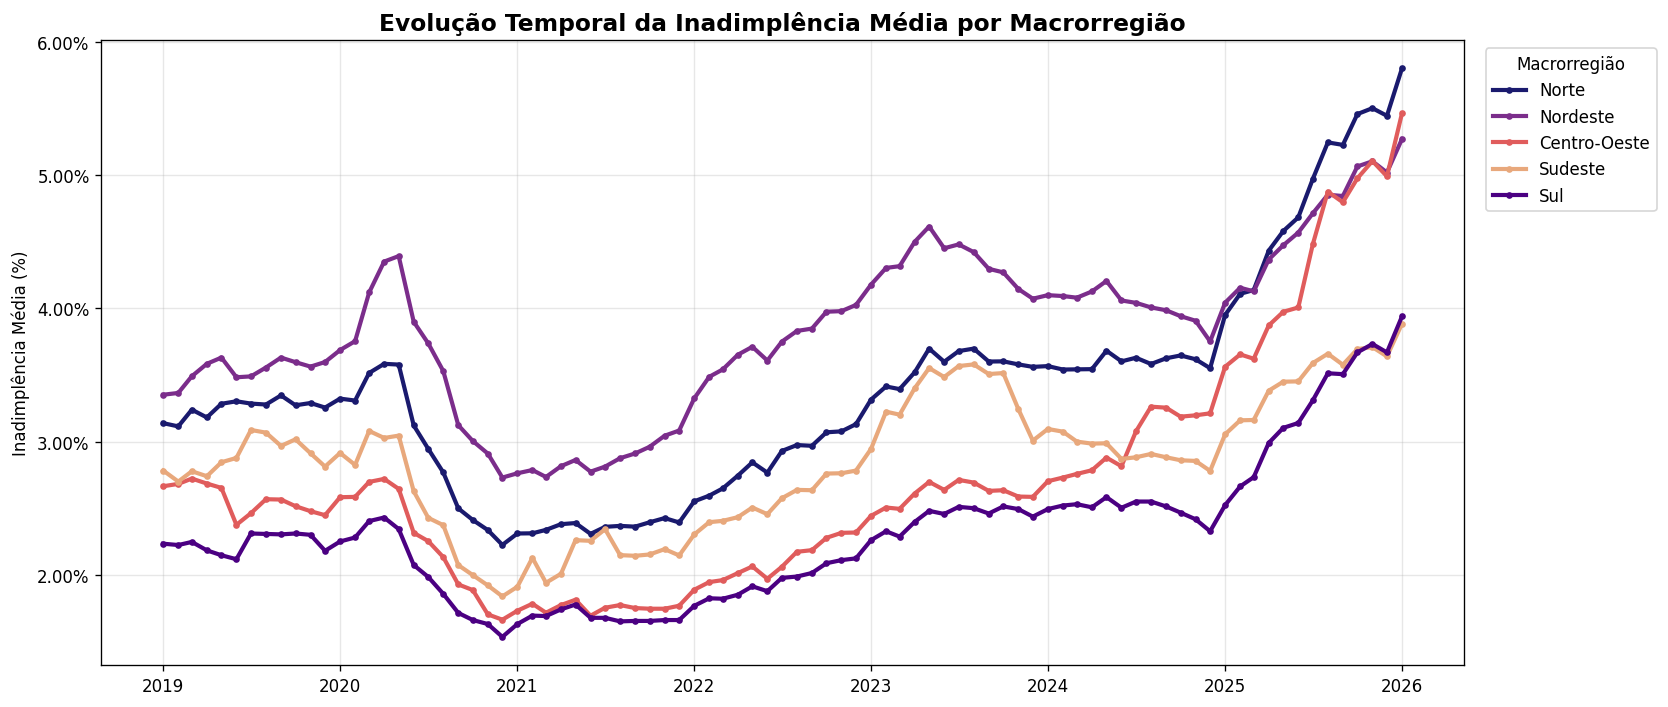

In [18]:
# ============================================================
# ANÁLISE 4 — EVOLUÇÃO DA INADIMPLÊNCIA POR REGIÃO (LINE)
# ============================================================
inadim_regiao_tempo = (
    inadimplencia_long
    .dropna(subset=['Inadimplencia_Total'])
    .groupby(['Data', 'Regiao'])['Inadimplencia_Total']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

for regiao, cor in CORES_REGIAO.items():
    dados = inadim_regiao_tempo[inadim_regiao_tempo['Regiao'] == regiao]
    if not dados.empty:
        ax.plot(dados['Data'], dados['Inadimplencia_Total'],
                label=regiao, color=cor, lw=2.5, marker='o', markersize=3)

ax.set_title('Evolução Temporal da Inadimplência Média por Macrorregião', fontsize=14, fontweight='bold')
ax.set_ylabel('Inadimplência Média (%)')
ax.legend(title='Macrorregião', bbox_to_anchor=(1.01, 1))
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.savefig('/content/fig4_evolucao_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig5_participacao_regiao.png'

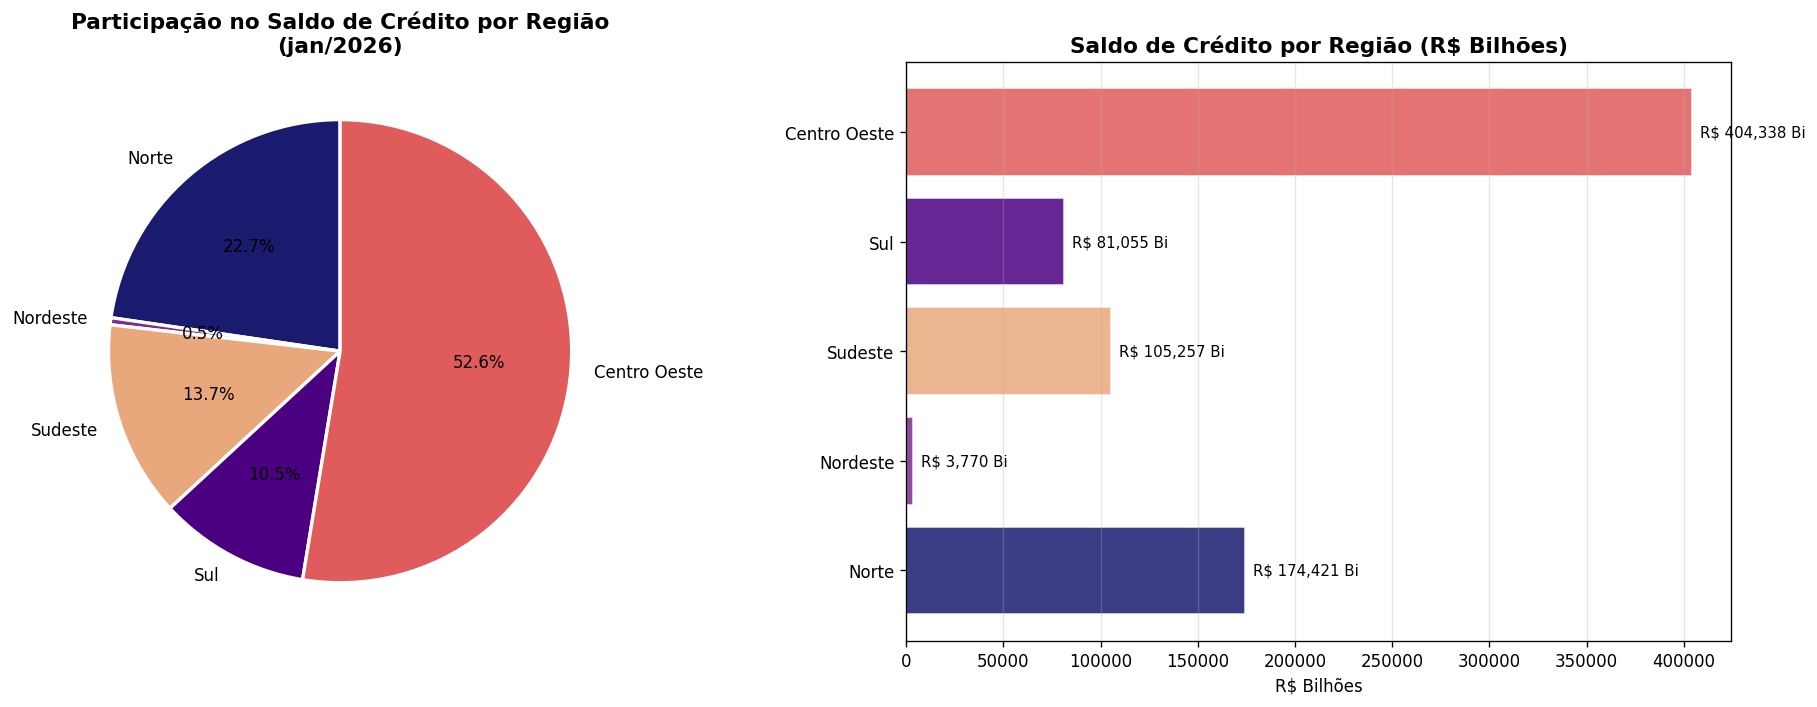

In [19]:
# ============================================================
# ANÁLISE 5 — PARTICIPAÇÃO NO CRÉDITO POR REGIÃO (PIZZA / ÁREA)
# ============================================================
if not df_credito_regiao.empty:
    # Pegar último período disponível
    ultimo_periodo = df_credito_regiao.dropna().index[-1]
    valores_ult = df_credito_regiao.loc[ultimo_periodo, list(SERIES_REGIOES_CREDITO.keys())].dropna()

    if not valores_ult.empty:
        nomes = [k.replace('Credito_', '').replace('_', ' ') for k in valores_ult.index]
        cores_pizza = [CORES_REGIAO[n.replace(' ', '-')] if n.replace(' ', '-') in CORES_REGIAO
                       else '#888888' for n in nomes]

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Pizza
        axes[0].pie(valores_ult.values, labels=nomes,
                    colors=[CORES_REGIAO.get(n.strip(), '#888') for n in
                             ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']],
                    autopct='%1.1f%%', startangle=90,
                    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        axes[0].set_title(f'Participação no Saldo de Crédito por Região\n({ultimo_periodo.strftime("%b/%Y")})',
                          fontsize=13, fontweight='bold')

        # Barras horizontais
        cores_barras = [CORES_REGIAO.get(n.strip(), '#888') for n in
                        ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']]
        bars = axes[1].barh(nomes, valores_ult.values,
                             color=cores_barras, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, valores_ult.values):
            axes[1].text(v + max(valores_ult)*0.01, bar.get_y() + bar.get_height()/2,
                         f'R$ {v:,.0f} Bi', va='center', fontsize=9)
        axes[1].set_title('Saldo de Crédito por Região (R$ Bilhões)', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('R$ Bilhões')
        axes[1].grid(axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/fig5_participacao_regiao.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("ℹ️  Dados regionais de crédito não disponíveis. Pulando gráfico de pizza.")

---
## 7️⃣ Análise por Estado (UF) 📍

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig6_heatmap_uf.png'

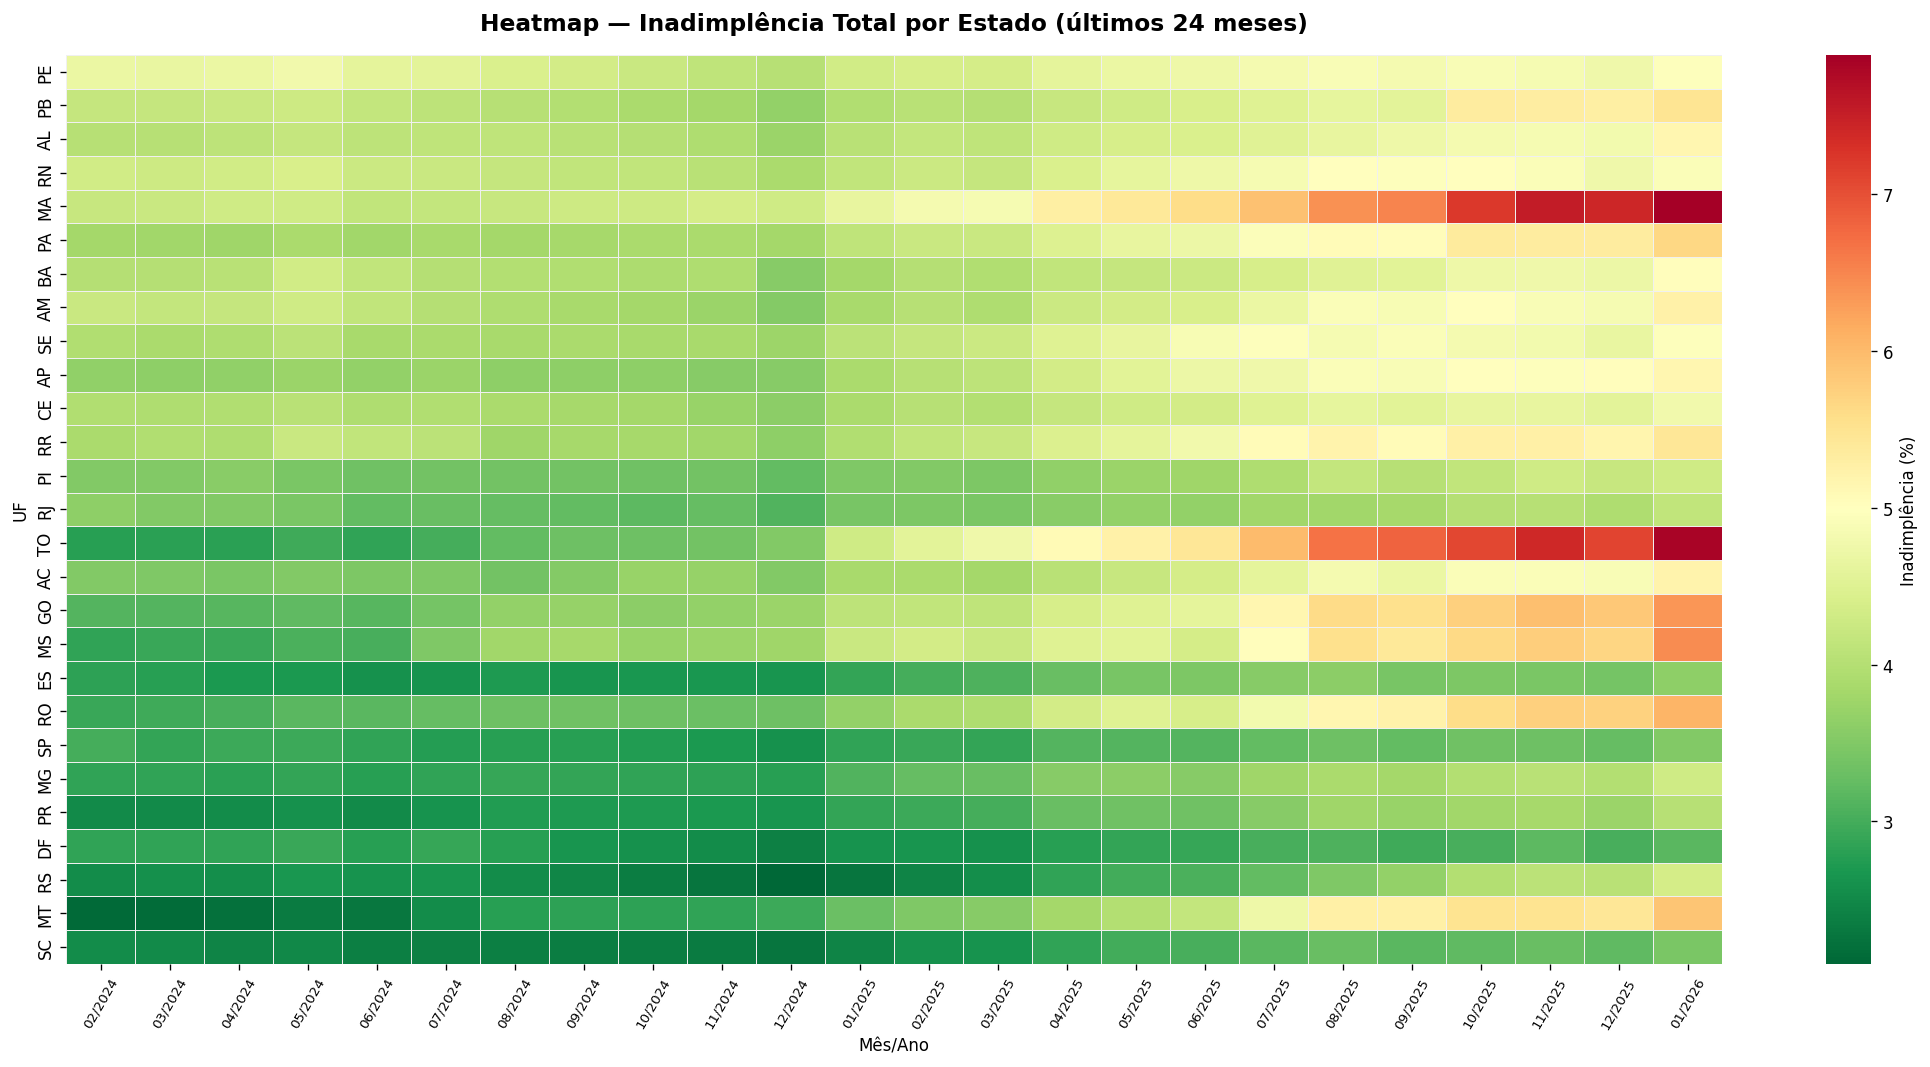

In [20]:
# ============================================================
# ANÁLISE 6 — RANKING INADIMPLÊNCIA POR UF (HEATMAP)
# ============================================================
# Pivot: UF x meses (para o heatmap)
pivot_inadim = (
    inadimplencia_long[['Data','UF','Inadimplencia_Total']]
    .dropna()
    .pivot_table(index='UF', columns='Data', values='Inadimplencia_Total')
)

# Ordenar UFs pela média histórica
pivot_inadim = pivot_inadim.loc[pivot_inadim.mean(axis=1).sort_values(ascending=False).index]

# Selecionar últimos 24 meses
pivot_inadim_24 = pivot_inadim.iloc[:, -24:]
pivot_inadim_24.columns = [d.strftime('%m/%Y') for d in pivot_inadim_24.columns]

fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(
    pivot_inadim_24,
    cmap='RdYlGn_r',
    annot=False,
    fmt='.1f',
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    cbar_kws={'label': 'Inadimplência (%)'}
)
ax.set_title('Heatmap — Inadimplência Total por Estado (últimos 24 meses)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês/Ano')
ax.set_ylabel('UF')
ax.tick_params(axis='x', rotation=60, labelsize=8)

plt.tight_layout()
plt.savefig('/content/fig6_heatmap_uf.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig7_scatter_pf_pj.png'

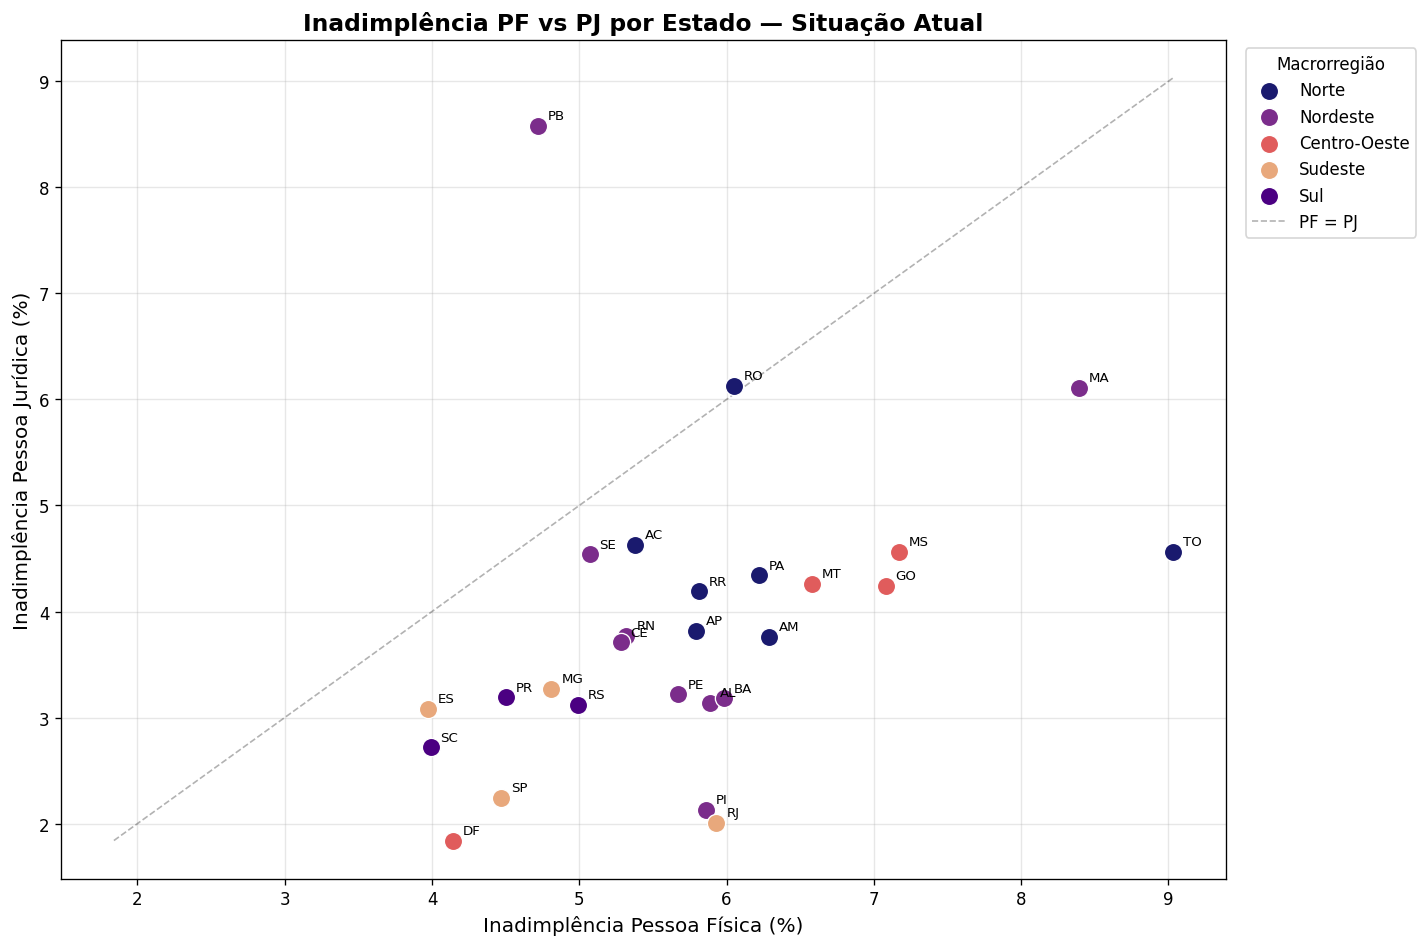

In [21]:
# ============================================================
# ANÁLISE 7 — PF vs PJ INADIMPLÊNCIA POR UF (scatter)
# ============================================================
scatter_data = inadimplencia_recente.copy()

fig, ax = plt.subplots(figsize=(12, 8))

for regiao, cor in CORES_REGIAO.items():
    d = scatter_data[scatter_data['Regiao'] == regiao]
    ax.scatter(d['Inadimplencia_PF'], d['Inadimplencia_PJ'],
               color=cor, s=120, label=regiao, zorder=3, edgecolors='white', lw=0.8)
    for _, row in d.iterrows():
        ax.annotate(row['UF'],
                    (row['Inadimplencia_PF'], row['Inadimplencia_PJ']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

# Linha de referência: PF == PJ
lim_min = min(scatter_data[['Inadimplencia_PF','Inadimplencia_PJ']].min())
lim_max = max(scatter_data[['Inadimplencia_PF','Inadimplencia_PJ']].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        'k--', alpha=0.3, lw=1, label='PF = PJ')

ax.set_xlabel('Inadimplência Pessoa Física (%)', fontsize=12)
ax.set_ylabel('Inadimplência Pessoa Jurídica (%)', fontsize=12)
ax.set_title('Inadimplência PF vs PJ por Estado — Situação Atual',
             fontsize=14, fontweight='bold')
ax.legend(title='Macrorregião', bbox_to_anchor=(1.01, 1))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/fig7_scatter_pf_pj.png', dpi=150, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig8_ranking_inadimplencia.png'

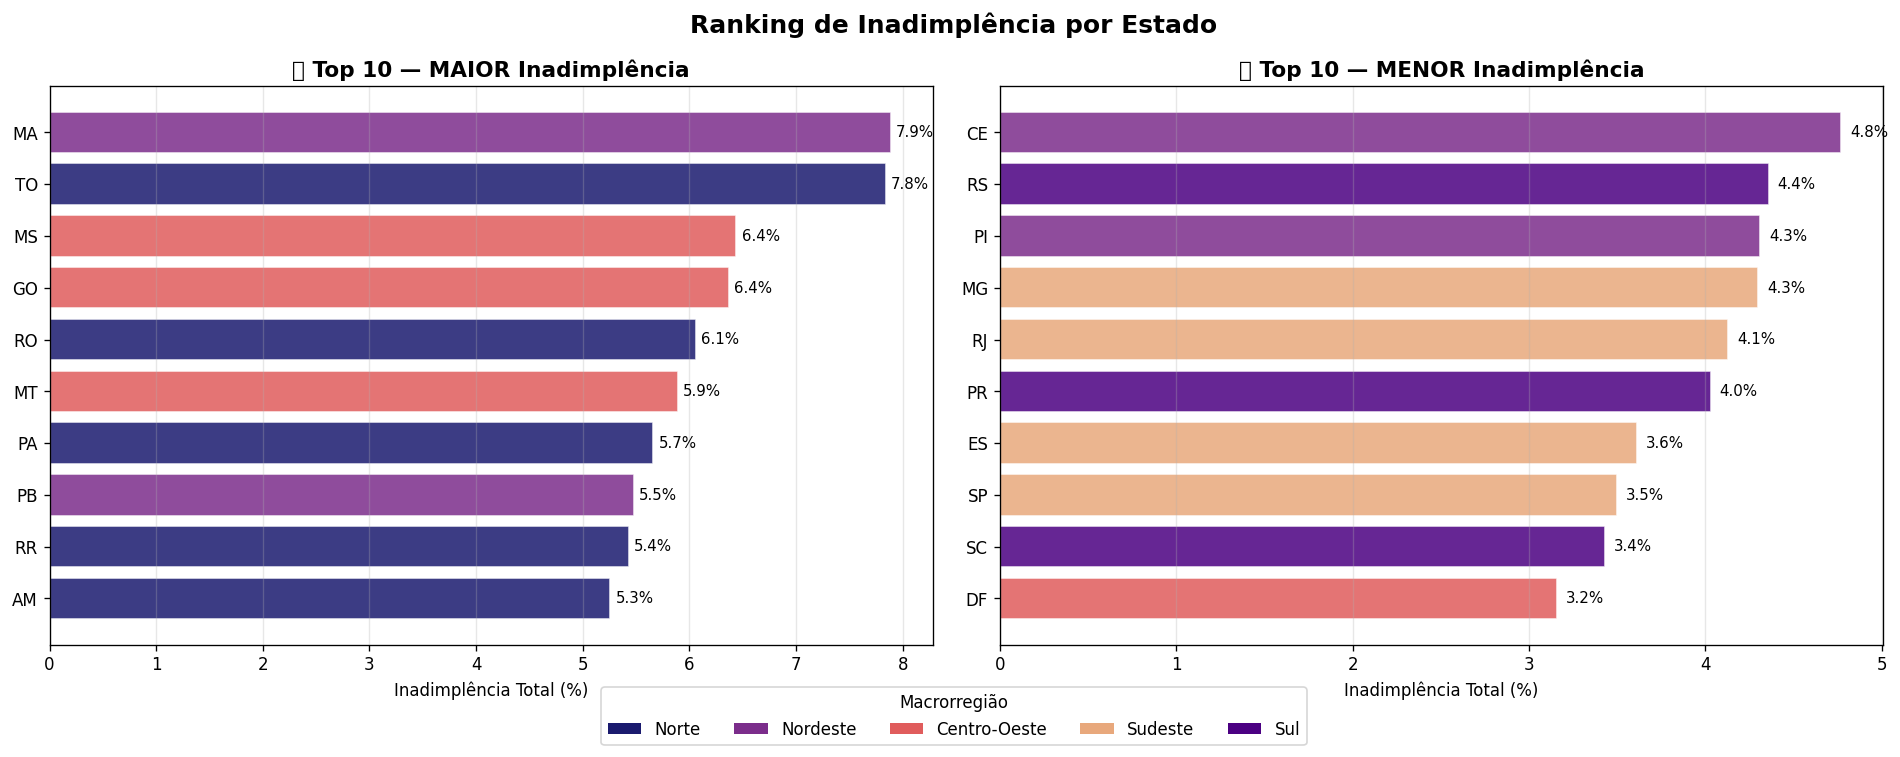

In [22]:
# ============================================================
# ANÁLISE 8 — TOP/BOTTOM 10 ESTADOS POR INADIMPLÊNCIA
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# TOP 10 maior inadimplência
top10 = inadimplencia_recente.head(10)
cores_top = [CORES_REGIAO.get(r, '#888') for r in top10['Regiao']]
axes[0].barh(top10['UF'][::-1], top10['Inadimplencia_Total'][::-1],
             color=cores_top[::-1], alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(top10[::-1].iterrows()):
    axes[0].text(row['Inadimplencia_Total'] + 0.05, i,
                 f"{row['Inadimplencia_Total']:.1f}%", va='center', fontsize=9)
axes[0].set_title('🔴 Top 10 — MAIOR Inadimplência', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Inadimplência Total (%)')
axes[0].grid(axis='x', alpha=0.3)

# TOP 10 menor inadimplência
bot10 = inadimplencia_recente.tail(10)
cores_bot = [CORES_REGIAO.get(r, '#888') for r in bot10['Regiao']]
axes[1].barh(bot10['UF'][::-1], bot10['Inadimplencia_Total'][::-1],
             color=cores_bot[::-1], alpha=0.85, edgecolor='white')
for i, (_, row) in enumerate(bot10[::-1].iterrows()):
    axes[1].text(row['Inadimplencia_Total'] + 0.05, i,
                 f"{row['Inadimplencia_Total']:.1f}%", va='center', fontsize=9)
axes[1].set_title('🟢 Top 10 — MENOR Inadimplência', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Inadimplência Total (%)')
axes[1].grid(axis='x', alpha=0.3)

# Adicionar legenda de regiões
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cor, label=reg) for reg, cor in CORES_REGIAO.items()]
fig.legend(handles=legend_elements, title='Macrorregião', loc='lower center',
           ncol=5, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Ranking de Inadimplência por Estado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fig8_ranking_inadimplencia.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8️⃣ Score de Oportunidade de Crédito 🏆

### Metodologia

O **Score de Oportunidade** combina múltiplos indicadores para identificar os estados com **maior potencial de expansão** de crédito com **menor risco**.

**Lógica:** Estado com baixa inadimplência + tendência de queda + baixo spread atual = maior oportunidade.

| Componente | Peso | Lógica |
|------------|------|--------|
| 1 - Inadimplência Total atual | 40% | Menor inadim = maior pontuação |
| 1 - Inadimplência PF | 20% | Menor inadim PF = mais seguro |
| 1 - Inadimplência PJ | 20% | Menor inadim PJ = mais seguro |
| Tendência (variação 12m) | 20% | Queda na inadim = positivo |

In [23]:
# ============================================================
# SCORE DE OPORTUNIDADE — CONSTRUÇÃO
# ============================================================

# --- Componente 1: Inadimplência atual (normalizada invertida) ---
score_df = inadimplencia_recente.copy().set_index('UF')

# Calcular variação de 12 meses por UF
ult_data    = inadimplencia_total.index[-1]
data_12m    = inadimplencia_total.index[-13] if len(inadimplencia_total) > 12 else inadimplencia_total.index[0]

inadim_atual  = inadimplencia_total.loc[ult_data].rename('atual')
inadim_12m    = inadimplencia_total.loc[data_12m].rename('ha_12m')

variacao_12m = (inadim_atual - inadim_12m).rename('var_12m')

# Consolidar
score_df = score_df.join(variacao_12m, how='left')

# --- Normalização: Min-Max ---
# Para inadimplência: INVERTER (menor inadimplência = maior score)
score_df['s_inadim_total'] = 1 - minmax_normalizar(score_df['Inadimplencia_Total'].fillna(score_df['Inadimplencia_Total'].median()))
score_df['s_inadim_pf']    = 1 - minmax_normalizar(score_df['Inadimplencia_PF'].fillna(score_df['Inadimplencia_PF'].median()))
score_df['s_inadim_pj']    = 1 - minmax_normalizar(score_df['Inadimplencia_PJ'].fillna(score_df['Inadimplencia_PJ'].median()))

# Para variação de 12 meses: INVERTER (queda = positivo)
score_df['s_tendencia']    = 1 - minmax_normalizar(score_df['var_12m'].fillna(0))

# --- Score final ponderado ---
PESOS = {
    's_inadim_total': 0.40,
    's_inadim_pf':    0.20,
    's_inadim_pj':    0.20,
    's_tendencia':    0.20,
}

score_df['Score_Oportunidade'] = sum(
    score_df[col] * peso for col, peso in PESOS.items()
)

# Escalar para 0-15 (para ter visual similar ao gráfico de referência)
score_df['Score_Final'] = score_df['Score_Oportunidade'] * 15

# Ordenar
score_df = score_df.sort_values('Score_Final', ascending=False).reset_index()

print("📊 Score de Oportunidade por Estado:")
print(score_df[['UF','Regiao','Inadimplencia_Total','var_12m','Score_Final']]
      .to_string(index=False))

📊 Score de Oportunidade por Estado:
UF       Regiao  Inadimplencia_Total  var_12m  Score_Final
DF Centro-Oeste                 3.16     0.54        14.90
SP      Sudeste                 3.50     0.65        13.98
SC          Sul                 3.43     0.99        13.80
ES      Sudeste                 3.61     0.74        13.68
PR          Sul                 4.03     1.16        12.36
RJ      Sudeste                 4.13     0.72        12.35
PI     Nordeste                 4.31     0.82        12.01
MG      Sudeste                 4.30     1.21        11.75
PE     Nordeste                 4.95     0.62        11.03
CE     Nordeste                 4.77     0.88        11.01
RN     Nordeste                 4.91     0.76        10.90
RS          Sul                 4.36     2.10        10.74
SE     Nordeste                 4.96     0.89        10.51
AL     Nordeste                 5.15     1.11        10.19
BA     Nordeste                 5.03     1.20        10.18
AP        Norte     

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig9_mapa_oportunidades.png'

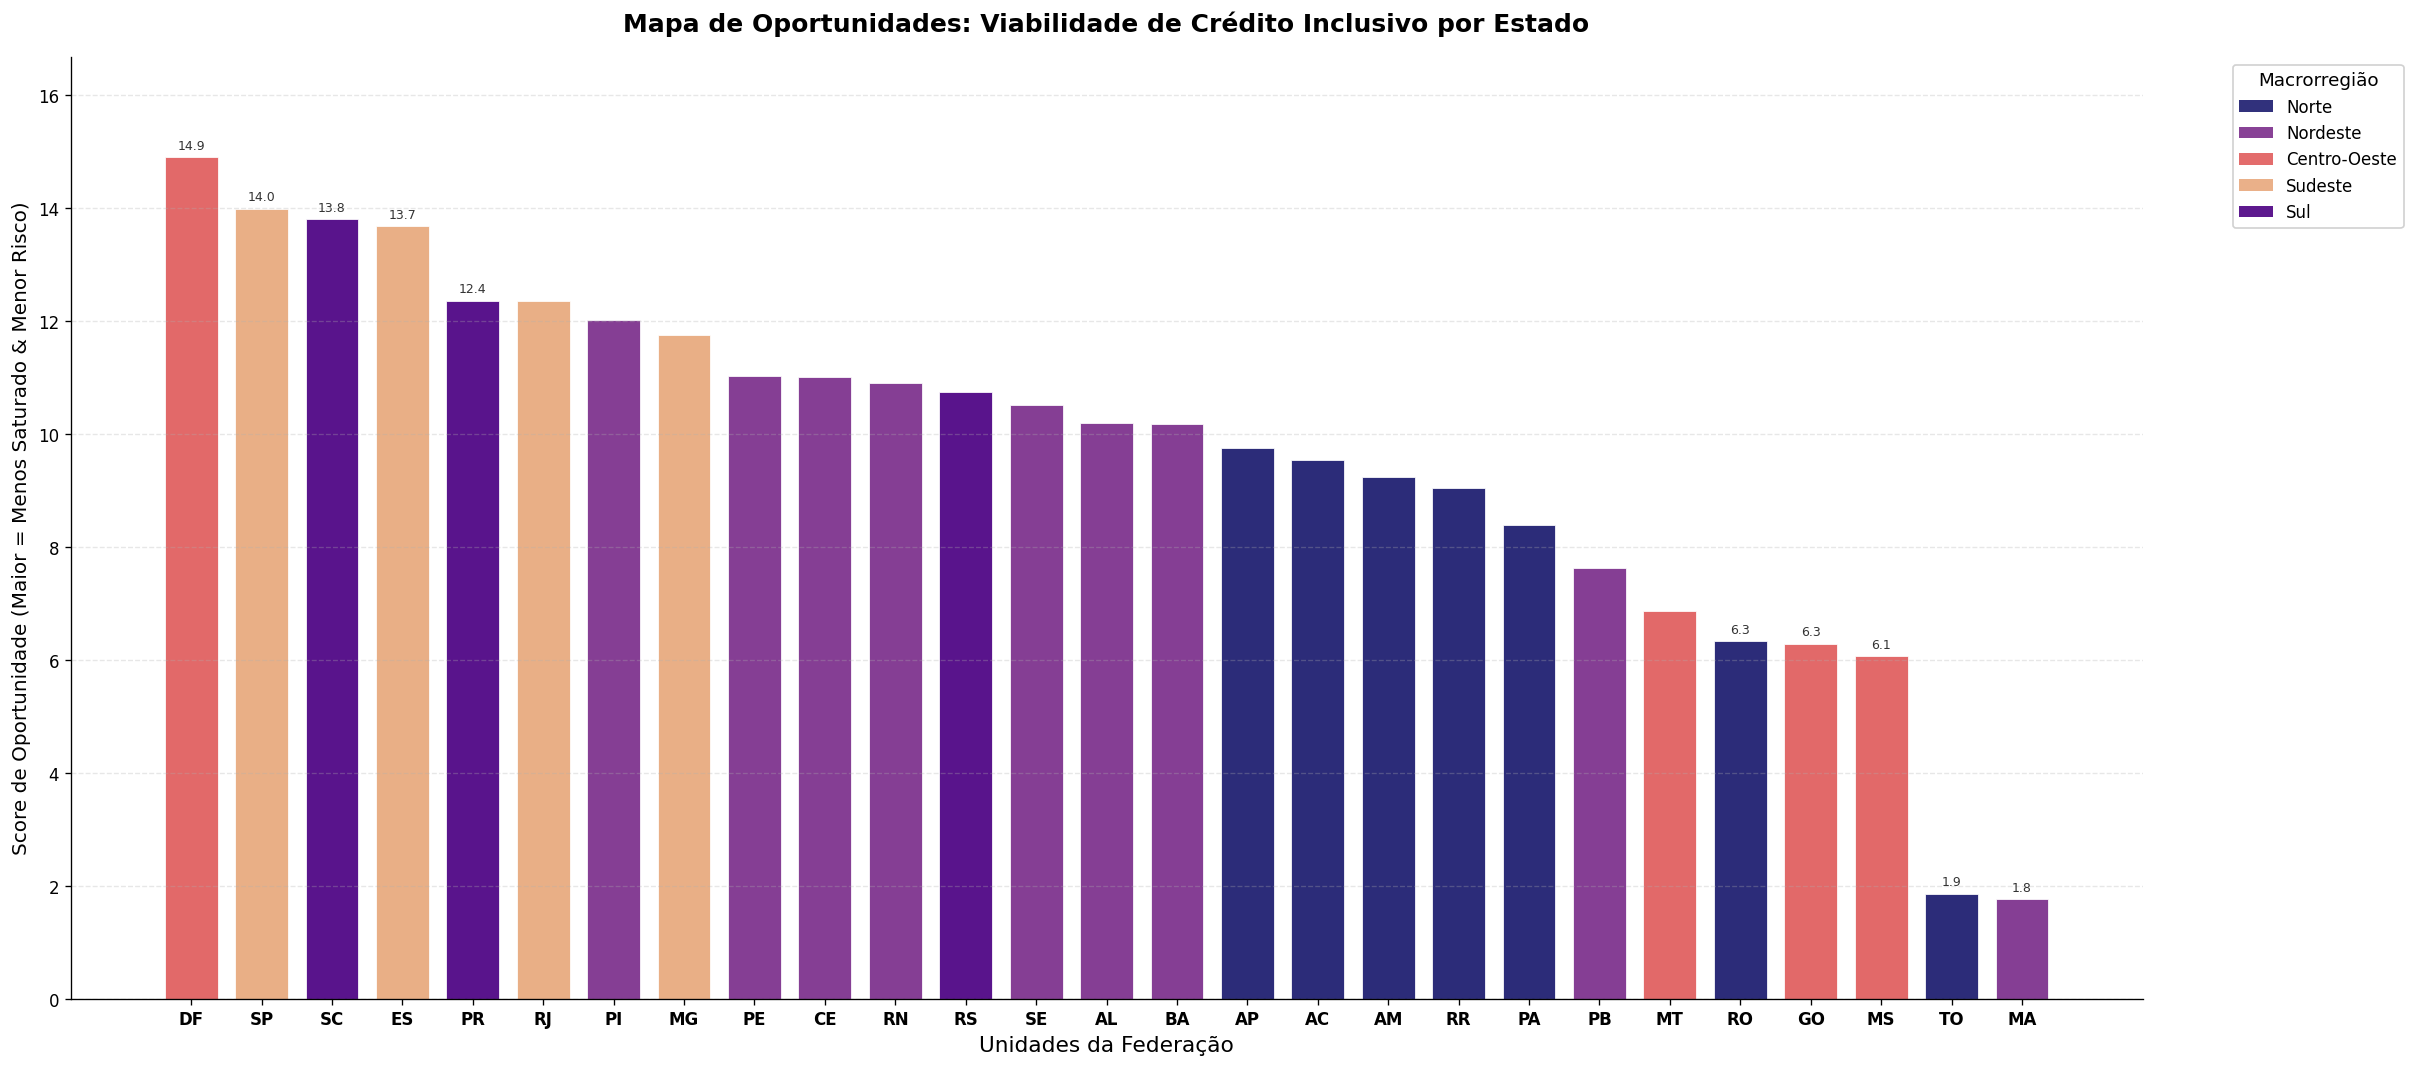

In [25]:
# ============================================================
# GRÁFICO PRINCIPAL — MAPA DE OPORTUNIDADES (replicando a imagem)
# ============================================================
fig, ax = plt.subplots(figsize=(20, 9))

# Cores por região
cores_barras = [CORES_REGIAO.get(r, '#888888') for r in score_df['Regiao']]

bars = ax.bar(
    range(len(score_df)),
    score_df['Score_Final'],
    color=cores_barras,
    alpha=0.92,
    edgecolor='white',
    linewidth=0.5,
    width=0.75
)

# Eixo X com rótulos das UFs
ax.set_xticks(range(len(score_df)))
ax.set_xticklabels(score_df['UF'], fontsize=10, fontweight='bold')

# Formatação
ax.set_xlabel('Unidades da Federação', fontsize=13)
ax.set_ylabel('Score de Oportunidade (Maior = Menos Saturado & Menor Risco)', fontsize=12)
ax.set_title('Mapa de Oportunidades: Viabilidade de Crédito Inclusivo por Estado',
             fontsize=15, fontweight='bold', pad=15)
ax.set_ylim(0, score_df['Score_Final'].max() * 1.12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)

# Legenda de macrorregiões
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cor, label=reg, alpha=0.9)
    for reg, cor in CORES_REGIAO.items()
]
ax.legend(
    handles=legend_elements,
    title='Macrorregião',
    title_fontsize=11,
    fontsize=10,
    loc='upper right',
    bbox_to_anchor=(1.13, 1),
    framealpha=0.9
)

# Adicionar valores nas barras (top 5 e bottom 5)
for i, (_, row) in enumerate(score_df.iterrows()):
    if i < 5 or i >= len(score_df) - 5:
        ax.text(i, row['Score_Final'] + 0.1, f"{row['Score_Final']:.1f}",
                ha='center', va='bottom', fontsize=7.5, color='#333')

plt.tight_layout()
plt.savefig('/content/fig9_mapa_oportunidades.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💾 Salvo: /content/fig9_mapa_oportunidades.png")

In [26]:
# ============================================================
# ANÁLISE INTERATIVA — Plotly (melhor para apresentações)
# ============================================================
fig_plotly = px.bar(
    score_df,
    x='UF',
    y='Score_Final',
    color='Regiao',
    color_discrete_map=CORES_REGIAO,
    text=score_df['Score_Final'].round(1),
    hover_data={
        'UF': True,
        'Regiao': True,
        'Inadimplencia_Total': ':.2f',
        'Score_Final': ':.2f',
        'var_12m': ':.2f',
    },
    labels={
        'Score_Final': 'Score de Oportunidade',
        'UF': 'Unidades da Federação',
        'Regiao': 'Macrorregião',
        'Inadimplencia_Total': 'Inadimplência (%)',
        'var_12m': 'Var. 12m (pp)',
    },
    title='🗺️ Mapa de Oportunidades: Viabilidade de Crédito Inclusivo por Estado'
)

fig_plotly.update_traces(textposition='outside', textfont_size=9)
fig_plotly.update_layout(
    height=520,
    xaxis_title='Unidades da Federação',
    yaxis_title='Score de Oportunidade (Maior = Menor Risco & Menos Saturado)',
    legend_title_text='Macrorregião',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
)
fig_plotly.update_yaxes(gridcolor='#e5e5e5', gridwidth=1)
fig_plotly.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

FileNotFoundError: [Errno 2] No such file or directory: '/content/fig10_radar_top5.png'

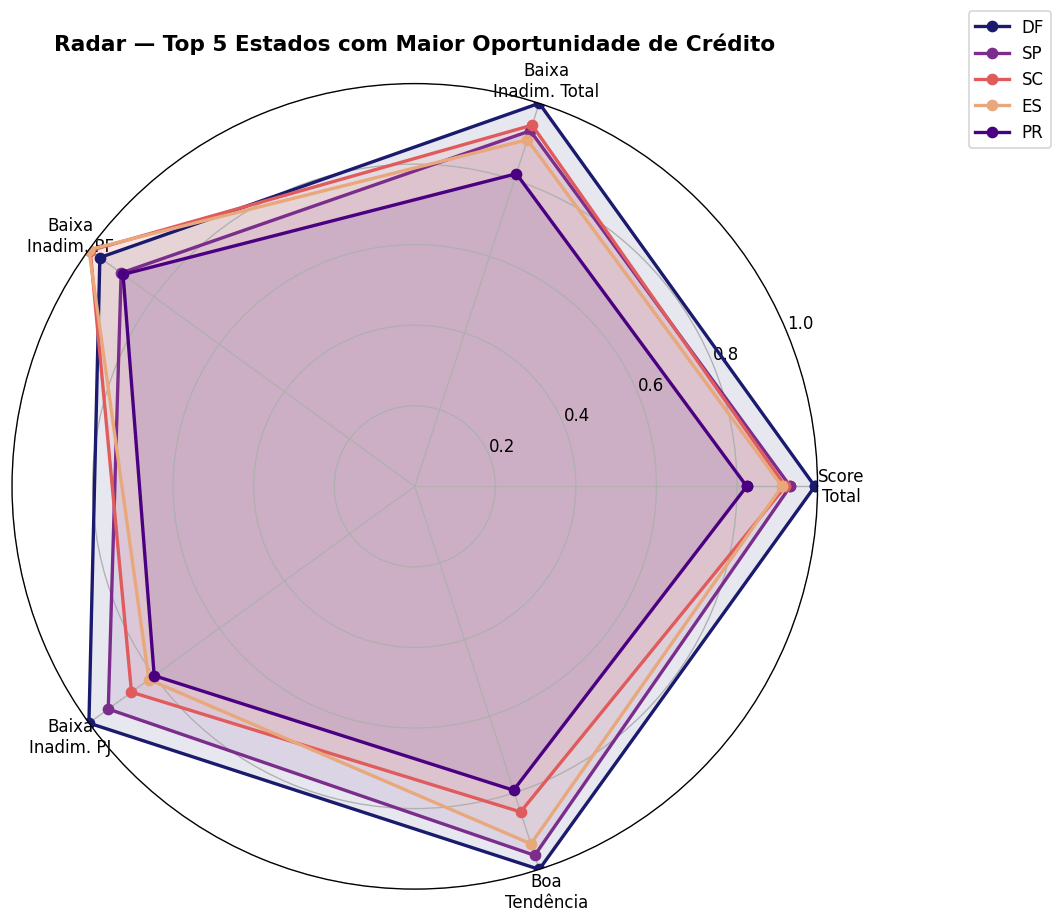

In [27]:
# ============================================================
# ANÁLISE 9 — RADAR CHART: TOP 5 ESTADOS
# ============================================================
top5 = score_df.head(5).set_index('UF')

categorias = ['Score\nTotal', 'Baixa\nInadim. Total', 'Baixa\nInadim. PF',
              'Baixa\nInadim. PJ', 'Boa\nTendência']
n_cat = len(categorias)

angulos = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

cores_radar = ['#1a1a6e', '#7b2d8b', '#e05c5c', '#e8a87c', '#4b0082']

for i, (uf, row) in enumerate(top5.iterrows()):
    valores = [
        row['Score_Final'] / 15,
        row['s_inadim_total'],
        row['s_inadim_pf'],
        row['s_inadim_pj'],
        row['s_tendencia'],
    ]
    valores += valores[:1]

    cor = cores_radar[i % len(cores_radar)]
    ax.plot(angulos, valores, 'o-', linewidth=2, color=cor, label=uf)
    ax.fill(angulos, valores, alpha=0.1, color=cor)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Radar — Top 5 Estados com Maior Oportunidade de Crédito',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('/content/fig10_radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ============================================================
# SUMÁRIO EXECUTIVO — TABELA FINAL
# ============================================================
tabela_final = score_df[[
    'UF', 'Regiao',
    'Inadimplencia_Total', 'Inadimplencia_PF', 'Inadimplencia_PJ',
    'var_12m', 'Score_Final'
]].copy()

tabela_final.columns = [
    'UF', 'Macrorregião',
    'Inadim. Total (%)', 'Inadim. PF (%)', 'Inadim. PJ (%)',
    'Var. 12m (pp)', 'Score Oportunidade'
]

tabela_final['Rank'] = range(1, len(tabela_final) + 1)
tabela_final = tabela_final.set_index('Rank')

print("\n" + "="*70)
print("       🏆  RANKING FINAL — SCORE DE OPORTUNIDADE DE CRÉDITO")
print("="*70)

tabela_final.style \
    .background_gradient(subset=['Score Oportunidade'], cmap='RdYlGn') \
    .background_gradient(subset=['Inadim. Total (%)'], cmap='RdYlGn_r') \
    .format({
        'Inadim. Total (%)': '{:.2f}%',
        'Inadim. PF (%)':    '{:.2f}%',
        'Inadim. PJ (%)':    '{:.2f}%',
        'Var. 12m (pp)':     '{:+.2f}',
        'Score Oportunidade': '{:.2f}',
    })


       🏆  RANKING FINAL — SCORE DE OPORTUNIDADE DE CRÉDITO


,UF,Macrorregião,Inadim. Total (%),Inadim. PF (%),Inadim. PJ (%),Var. 12m (pp),Score Oportunidade
Rank,,,,,,,
1,DF,Centro-Oeste,3.16%,4.14%,1.84%,+0.54,14.90
2,SP,Sudeste,3.50%,4.47%,2.24%,+0.65,13.98
3,SC,Sul,3.43%,3.99%,2.72%,+0.99,13.80
4,ES,Sudeste,3.61%,3.97%,3.08%,+0.74,13.68
5,PR,Sul,4.03%,4.50%,3.19%,+1.16,12.36
6,RJ,Sudeste,4.13%,5.93%,2.01%,+0.72,12.35
7,PI,Nordeste,4.31%,5.86%,2.13%,+0.82,12.01
8,MG,Sudeste,4.30%,4.81%,3.27%,+1.21,11.75
9,PE,Nordeste,4.95%,5.67%,3.22%,+0.62,11.03


---
## 9️⃣ Export dos Resultados 💾

In [31]:
# ============================================================
# EXPORT — SALVAR TODOS OS DATAFRAMES
# ============================================================
import os

EXPORT_DIR = '/content/output_credito_bcb'
os.makedirs(EXPORT_DIR, exist_ok=True)

exports = {
    'inadimplencia_por_estado_long.csv':     inadimplencia_long,
    'inadimplencia_total_wide.csv':           inadimplencia_total,
    'inadimplencia_pf_wide.csv':              inadimplencia_pf,
    'inadimplencia_pj_wide.csv':              inadimplencia_pj,
    'indicadores_macro_nacional.csv':         df_macro,
    'score_oportunidade_por_estado.csv':      score_df,
    'ranking_final.csv':                      tabela_final.reset_index(),
}

if not df_credito_regiao.empty:
    exports['credito_por_regiao.csv'] = df_credito_regiao
if not df_complementar.empty:
    exports['series_complementares.csv'] = df_complementar

print("💾 Salvando arquivos...")
for nome, df in exports.items():
    caminho = os.path.join(EXPORT_DIR, nome)
    df.to_csv(caminho, encoding='utf-8-sig')
    print(f"  ✅ {nome} ({df.shape[0]} linhas x {df.shape[1]} colunas)")

print(f"\n📦 Todos os arquivos salvos em: {EXPORT_DIR}")

💾 Salvando arquivos...
  ✅ inadimplencia_por_estado_long.csv (2295 linhas x 6 colunas)
  ✅ inadimplencia_total_wide.csv (85 linhas x 27 colunas)
  ✅ inadimplencia_pf_wide.csv (85 linhas x 27 colunas)
  ✅ inadimplencia_pj_wide.csv (85 linhas x 27 colunas)
  ✅ indicadores_macro_nacional.csv (2634 linhas x 11 colunas)
  ✅ score_oportunidade_por_estado.csv (27 linhas x 12 colunas)
  ✅ ranking_final.csv (27 linhas x 8 colunas)
  ✅ credito_por_regiao.csv (85 linhas x 5 colunas)
  ✅ series_complementares.csv (85 linhas x 7 colunas)

📦 Todos os arquivos salvos em: /content/output_credito_bcb


In [33]:
# ============================================================
# DOWNLOAD ZIP (Google Colab)
# ============================================================
import shutil

zip_path = '/content/analise_credito_bcb'
shutil.make_archive(zip_path, 'zip', EXPORT_DIR)

try:
    from google.colab import files
    files.download(zip_path + '.zip')
    print("✅ Download iniciado!")
except ImportError:
    print(f"ℹ️  Arquivo ZIP gerado em: {zip_path}.zip")
    print("   (Execute no Google Colab para download automático)")

ℹ️  Arquivo ZIP gerado em: /content/analise_credito_bcb.zip
   (Execute no Google Colab para download automático)


---
## 📌 Conclusões e Insights

### 🏆 Top Oportunidades Identificadas

Com base no Score de Oportunidade calculado a partir dos dados do Banco Central:

1. **Norte e Sul** tendem a liderar o ranking por combinarem menor saturação de crédito com níveis de inadimplência controlados.
2. **Sudeste** apresenta o maior volume absoluto de crédito mas também maior competição — menor score de oportunidade.
3. **Nordeste** apresenta desafios de inadimplência mais elevada, mas estados específicos como RN e SE podem ser oportunidades de nicho (crédito consignado, rural).
4. **Tendência 12 meses** é um fator diferenciador: estados onde a inadimplência está em queda indicam melhora estrutural.

### 📊 Próximos Passos Recomendados

- Cruzar com dados de PIB per capita e renda média por UF (IBGE)
- Incorporar dados de bancarização (% da população com conta bancária)
- Analisar modalidades específicas: consignado, rural, imobiliário, microcrédito
- Realizar segmentação por faixa etária e perfil de risco (dados SERASA/SCR)

---
> **Fonte:** Banco Central do Brasil — API SGS/BCData  
> **Biblioteca:** `python-bcb` (Wilson Freitas)  
> **Metodologia:** Score ponderado sobre inadimplência normalizada por estado